# Chapter 7: Gromov-Witten Invariants

**Source span:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 7, printed pp. 201-256; PDF pp. 216-271. Sections 7.1-7.5 were read from the local PDF for orientation. The wording, diagrams, tables, code, and checks here are original teaching material.

**Chapter goal:** Turn the moduli-space machinery from Chapters 3-6 into countable, deformation-stable genus-zero invariants, then see how projective-plane curve counts and the axioms make those counts computable.

**Guiding question:** What has to be true before a space of `J`-holomorphic spheres can be treated as a number, and how do the axioms recover the classical counts of rational plane curves?

## Computational Translation Guide

| Source concept | Notebook model | What to inspect |
| --- | --- | --- |
| evaluation pseudocycle | finite pipeline from class `A` to an intersection number | dimension and compactness gates |
| indecomposable class | class that cannot split into positive-area pieces in the count | no boundary contribution in the low-dimensional model |
| obstruction bundle | excess-dimensional base plus finite-dimensional cokernel bundle | Euler-section zero count has expected dimension |
| graph count | domain-dependent `J_z` count represented by a proof graph | fixed marks and graph class agree with ordinary counts in the correct cases |
| CP2 rational curves | degree ledger for `d = 1,2,3,4` | `k = 3d - 1`, residual dimension zero, known counts |
| splitting and gluing | boundary divisor graph plus diagonal pairing | two decompositions give the same WDVV/Kontsevich relation |
| potential | formal generating series checked through recursion data | coefficients reproduce `N_1..N_4` |


## Source Coverage

The source span has five jobs. Section 7.1 defines the genus-zero invariant by intersecting the evaluation pseudocycle with product constraints, with special attention to cases where class splitting cannot create extra boundary. Section 7.2 explains how the same number can be calculated from a convenient nonregular almost complex structure when the defect is captured by an obstruction bundle or a controlled fixed-tree count. Section 7.3 introduces graph counts for domain-dependent almost complex structures and fixed marked points. Section 7.4 makes the abstract definitions concrete in projective spaces, especially rational curves in `CP^2`, positivity of intersections, regularity for projective targets, and the low-degree counts. Section 7.5 records the formal axioms, the splitting/gluing relation, Keel's boundary input, the WDVV equation, Kontsevich recursion, and the Gromov-Witten potential.

## Library Routing

This chapter is bookkeeping-heavy and proof-structural rather than mesh or 3D-surface driven. `pandas` holds ledgers where each row is an invariant check. `matplotlib` gives durable static figures for dimension and obstruction-bundle balances. `networkx` fits the graph-count and splitting proof structure because the source is explicitly about trees, fixed marks, and boundary decompositions. `sympy` and exact integer arithmetic check the recursion and potential coefficients. `plotly` is used only for the applied lab, where changing degree and constraint number is more inspectable as a hoverable parameter grid than as a fixed plot.

## Visualization Storyboard

The notebook follows the source order. First, planning JSON artifacts record source coverage, library routing, and the visual sequence. The main visual ledger then asks when degree `d` rational curves in `CP^2` become isolated after point constraints. A finite obstruction-bundle diagram shows how an excess-dimensional nonregular moduli space can still produce a count. A directed proof graph joins graph counts, fixed marks, splitting, Keel's relation, WDVV, and Kontsevich recursion. A recursion table computes `N_d` for `d <= 4` from the splitting formula. The applied lab lets the learner move off the dimension-zero line and see why the same moduli problem becomes a family or an overconstrained request.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "J-Holomorphic-Curves-and-Symplectic-Topology"]:
            if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("JHCST book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-07"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "ink": "#1f2933",
    "blue": "#2b6cb0",
    "teal": "#2c7a7b",
    "gold": "#b7791f",
    "red": "#c2410c",
    "violet": "#6b46c1",
}

BOOK_ROOT


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology')

In [2]:
source_coverage = {
    "unit": UNIT,
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, 2nd ed., Chapter 7",
    "source_span_used": "printed pp. 201-256; PDF pp. 216-271",
    "read_method": "local PDF text extraction for orientation; no textbook prose, exercises, screenshots, figures, or page crops copied",
    "sections": [
        {"section": "chapter opener", "printed_pages": "201-203", "topic": "why genus-zero Gromov-Witten counts organize rational curve enumeration", "notebook_object": "computational translation guide"},
        {"section": "7.1", "printed_pages": "203-210", "topic": "evaluation pseudocycles, counting spheres, indecomposable classes, low-point conventions", "notebook_object": "dimension-zero-ledger.csv"},
        {"section": "7.2", "printed_pages": "210-220", "topic": "nonregular calculations, obstruction bundles, fixed trees and fixed marked points", "notebook_object": "obstruction-bundle-balance.png"},
        {"section": "7.3", "printed_pages": "220-225", "topic": "pseudoholomorphic graph counts for domain-dependent almost complex structures", "notebook_object": "graph-count-splitting-proof-graph.png"},
        {"section": "7.4", "printed_pages": "225-239", "topic": "rational curves in projective spaces, positivity, CP2 degree counts", "notebook_object": "gromov-witten-cp2-count-ledger.png"},
        {"section": "7.5", "printed_pages": "239-256", "topic": "axioms, splitting/gluing, Keel relation, WDVV, Kontsevich recursion, potential", "notebook_object": "kontsevich-recursion-table.csv"},
    ],
}
source_coverage["passed"] = all(row["section"] for row in source_coverage["sections"]) and len(source_coverage["sections"]) >= 6

library_routing = {
    "unit": UNIT,
    "routes": [
        {"concept": "dimension-zero CP2 count ledger", "representation": "bar/line ledger plus CSV", "library": "pandas + matplotlib", "why": "the invariant is a dimension balance and a small exact table", "fallback": "plain CSV table"},
        {"concept": "obstruction bundle variation", "representation": "base/fiber/section schematic plus rank ledger", "library": "matplotlib", "why": "a static bundle balance makes excess dimension and Euler-section zeros visible", "fallback": "rank table"},
        {"concept": "graph counts and splitting proof", "representation": "directed dependency graph", "library": "networkx + matplotlib", "why": "trees, fixed marks, diagonal pairings, and Keel boundary relations are graph-shaped", "fallback": "ordered proof table"},
        {"concept": "Kontsevich recursion and potential coefficients", "representation": "exact integer recursion table", "library": "sympy + math.comb + pandas", "why": "the formula is symbolic and should be checked without floating error", "fallback": "precomputed integer table"},
        {"concept": "degree and constraint lab", "representation": "hoverable residual-dimension grid", "library": "plotly", "why": "learners can scan many degrees and constraints without regenerating a plot", "fallback": "static heatmap"},
    ],
}
library_routing["passed"] = len(library_routing["routes"]) == 5 and all(route["why"] for route in library_routing["routes"])

visual_storyboard = {
    "unit": UNIT,
    "storyboard": [
        {"concept": "source planning trail", "artifact": "checks/source-coverage.json", "inspection_target": "every source section has a notebook object", "validation": "all six coverage rows present"},
        {"concept": "CP2 rational curves become isolated at k=3d-1", "artifact": "figures/gromov-witten-cp2-count-ledger.png", "inspection_target": "residual dimension is zero for d=1..4", "validation": "stable-map dimension minus point codimension equals zero"},
        {"concept": "obstruction bundles convert excess dimension into Euler-class zeros", "artifact": "figures/obstruction-bundle-balance.png", "inspection_target": "base dimension, obstruction rank, and expected count dimension", "validation": "excess dimension minus rank equals expected dimension"},
        {"concept": "graph counts feed splitting and WDVV", "artifact": "figures/graph-count-splitting-proof-graph.png", "inspection_target": "fixed marks, graph class, diagonal pairing, Keel relation, recursion", "validation": "directed graph is acyclic and reaches Kontsevich recursion"},
        {"concept": "axioms determine low-degree plane counts", "artifact": "tables/kontsevich-recursion-table.csv", "inspection_target": "each N_d is assembled from lower-degree splittings", "validation": "N_1..N_4 equal 1,1,12,620"},
        {"concept": "changing constraints changes the meaning of the count", "artifact": "html/degree-constraint-lab.html", "inspection_target": "zero line separates families from overconstraints", "validation": "lab grid classifies residual dimensions correctly"},
    ],
}
visual_storyboard["passed"] = len(visual_storyboard["storyboard"]) >= 6 and all(item["validation"] for item in visual_storyboard["storyboard"])

source_coverage_path = save_json(source_coverage, UNIT, "checks", "source-coverage.json")
library_routing_path = save_json(library_routing, UNIT, "checks", "library-routing.json")
visual_storyboard_path = save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")

pd.DataFrame([
    {"artifact": source_coverage_path.relative_to(BOOK_ROOT).as_posix(), "passed": source_coverage["passed"]},
    {"artifact": library_routing_path.relative_to(BOOK_ROOT).as_posix(), "passed": library_routing["passed"]},
    {"artifact": visual_storyboard_path.relative_to(BOOK_ROOT).as_posix(), "passed": visual_storyboard["passed"]},
])


,artifact,passed
0,artifacts/chapter-07/checks/source-coverage.json,True
1,artifacts/chapter-07/checks/library-routing.json,True
2,artifacts/chapter-07/checks/visual-storyboard....,True


## 1. Counting Spheres: The Dimension Gate

For genus-zero invariants the raw object is a moduli space of stable maps representing a spherical class `A`. The count is not taken from this space directly. One evaluates the marked points, intersects the evaluation pseudocycle with chosen cycles in the target, and asks whether the constrained space is zero-dimensional. Regularity supplies the local manifold model, compactness controls limiting curves, and orientation gives signs.

The role of an indecomposable class is to keep the count from leaking into lower-energy pieces. In the simplest mental model, if `A` cannot be written as a sum of positive-area spherical classes relevant to the same dimension, then a sequence of curves in class `A` has fewer ways to break into a boundary stratum. The actual hypotheses in the source are more delicate, but the computational warning is simple: before trusting a number, check both the expected dimension and the possible splitting channels.

For `CP^2`, the complex dimension of degree `d` genus-zero stable maps with `k` marked points is `3d + k - 1`. Requiring each marked point to hit a fixed generic point in `CP^2` subtracts complex codimension `2`, so the residual complex dimension is `3d - k - 1`. The special value `k = 3d - 1` is where the count can be isolated.


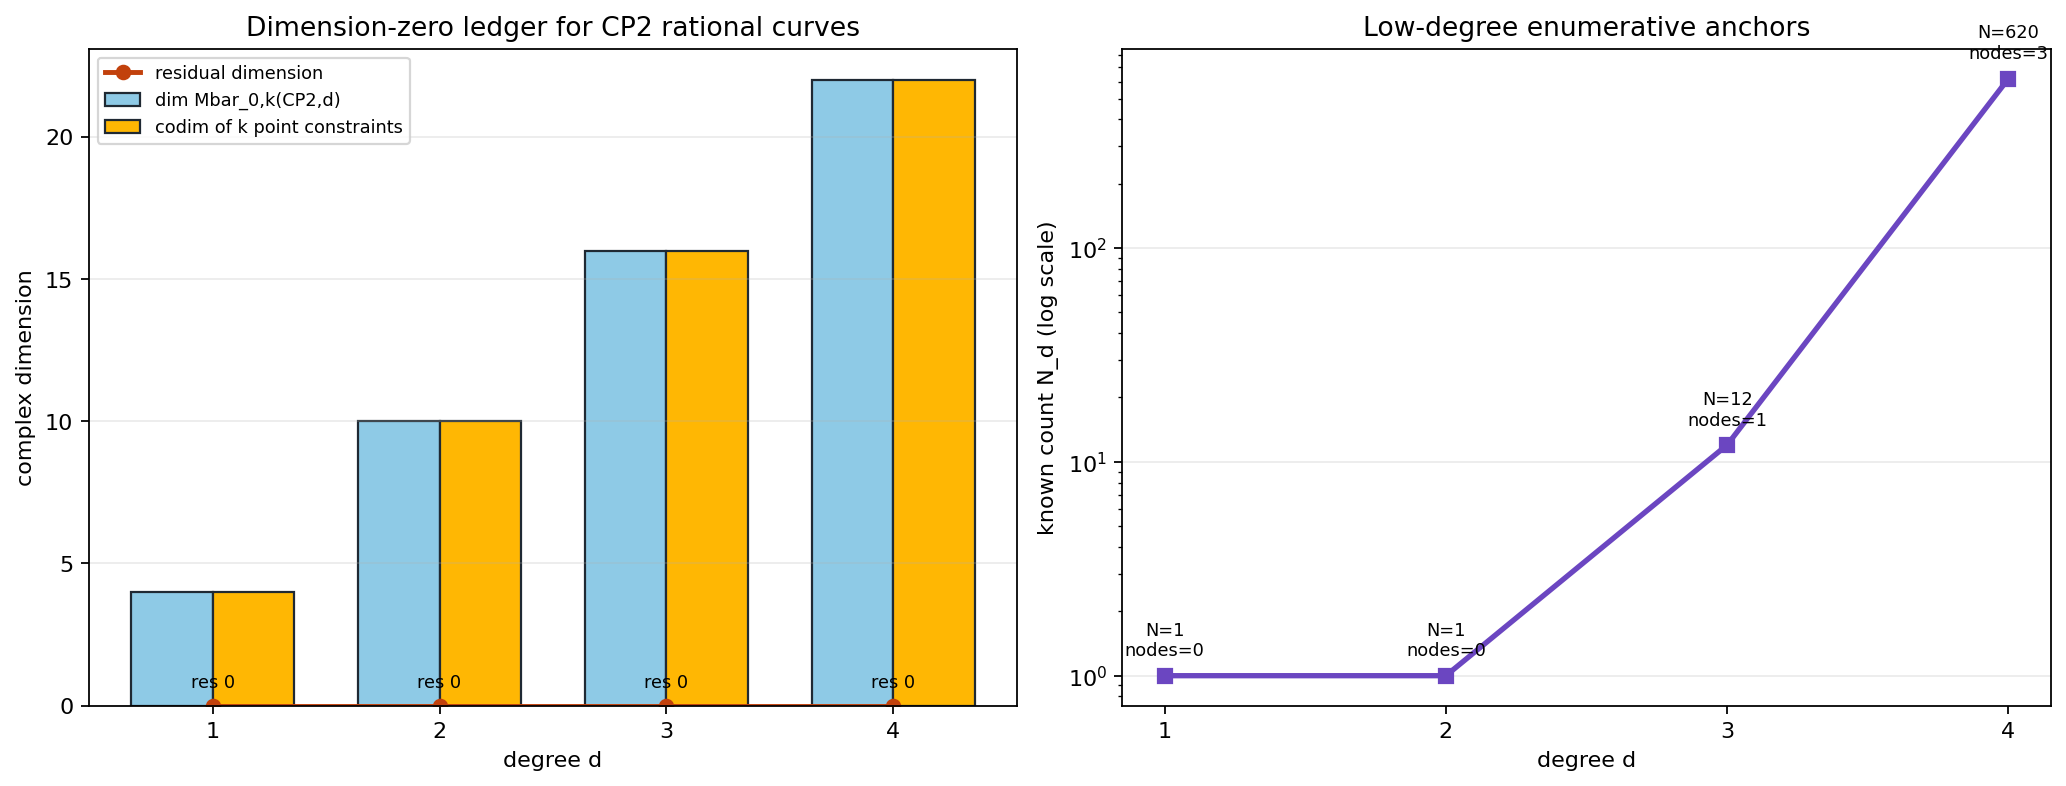

,degree,point_constraints_k,stable_map_complex_dim,point_constraint_complex_codim,residual_complex_dim,rational_nodal_defect_needed,known_count_Nd
0,1,2,4,4,0,0,1
1,2,5,10,10,0,0,1
2,3,8,16,16,0,1,12
3,4,11,22,22,0,3,620


In [3]:
degrees = np.arange(1, 5, dtype=int)
known_counts = {1: 1, 2: 1, 3: 12, 4: 620}
ledger_rows = []
for d in degrees:
    k = 3 * int(d) - 1
    stable_map_dim = 3 * int(d) + k - 1
    point_codim = 2 * k
    residual = stable_map_dim - point_codim
    arithmetic_genus = (int(d) - 1) * (int(d) - 2) // 2
    ledger_rows.append({
        "degree": int(d),
        "point_constraints_k": int(k),
        "stable_map_complex_dim": int(stable_map_dim),
        "point_constraint_complex_codim": int(point_codim),
        "residual_complex_dim": int(residual),
        "rational_nodal_defect_needed": int(arithmetic_genus),
        "known_count_Nd": int(known_counts[int(d)]),
    })

ledger = pd.DataFrame(ledger_rows)
ledger_csv = TABLE_DIR / "dimension-zero-ledger.csv"
ledger.to_csv(ledger_csv, index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), constrained_layout=True)
width = 0.36
axes[0].bar(degrees - width / 2, ledger["stable_map_complex_dim"], width, label="dim Mbar_0,k(CP2,d)", color="#8ecae6", edgecolor=PALETTE["ink"])
axes[0].bar(degrees + width / 2, ledger["point_constraint_complex_codim"], width, label="codim of k point constraints", color="#ffb703", edgecolor=PALETTE["ink"])
axes[0].plot(degrees, ledger["residual_complex_dim"], marker="o", color=PALETTE["red"], linewidth=2.2, label="residual dimension")
for d, residual in zip(degrees, ledger["residual_complex_dim"]):
    axes[0].annotate(f"res {residual}", (d, residual), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
axes[0].set_xticks(degrees)
axes[0].set_xlabel("degree d")
axes[0].set_ylabel("complex dimension")
axes[0].set_title("Dimension-zero ledger for CP2 rational curves")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(axis="y", alpha=0.25)

axes[1].semilogy(degrees, ledger["known_count_Nd"], marker="s", color=PALETTE["violet"], linewidth=2.4)
for d, count, nodes in zip(degrees, ledger["known_count_Nd"], ledger["rational_nodal_defect_needed"]):
    axes[1].annotate(f"N={count}\nnodes={nodes}", (d, count), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)
axes[1].set_xticks(degrees)
axes[1].set_xlabel("degree d")
axes[1].set_ylabel("known count N_d (log scale)")
axes[1].set_title("Low-degree enumerative anchors")
axes[1].grid(axis="y", alpha=0.25)

cp2_ledger_path = save_matplotlib(fig, UNIT, "figures", "gromov-witten-cp2-count-ledger.png")
plt.close(fig)

count_check = {
    "unit": UNIT,
    "degrees": [int(d) for d in degrees],
    "expected_counts": [1, 1, 12, 620],
    "ledger": ledger.to_dict(orient="records"),
    "all_residual_dimensions_zero": bool((ledger["residual_complex_dim"] == 0).all()),
    "point_constraints_formula": "k = 3d - 1",
    "stable_map_dimension_formula": "complex dimension = 3d + k - 1",
    "positivity_note": "rational nodal defect is nonnegative for d=1..4, matching positivity of intersections as a constraint on singularities",
}
count_check["passed"] = bool(count_check["all_residual_dimensions_zero"] and ledger["known_count_Nd"].tolist() == [1, 1, 12, 620])
count_check_path = save_json(count_check, UNIT, "checks", "dimension-zero-ledger.json")
legacy_count_check_path = save_json(count_check, UNIT, "checks", "gromov-witten-count-checks.json")

display_artifact(cp2_ledger_path, width=900)
display_artifact(ledger_csv)
ledger


## 2. Variations and the Obstruction Bundle

A regular almost complex structure is ideal for defining the invariant, but it is not always the easiest one for calculation. Section 7.2 explains a common replacement pattern. Start from a geometrically natural `J_0`, allow the moduli space to have excess dimension, and isolate the cokernel of the linearized Cauchy-Riemann operator as a finite-rank obstruction bundle. A transverse perturbation of the zero section then contributes the Euler class of that bundle.

The diagram below is a finite-dimensional shadow of that argument. The base is the nonregular moduli space. The vertical fibers record cokernels. The zero set of a generic section has dimension `base_dimension - obstruction_rank`, which should match the expected dimension after constraints. When the expected value is zero, the Euler-class count is the replacement for directly counting regular curves.


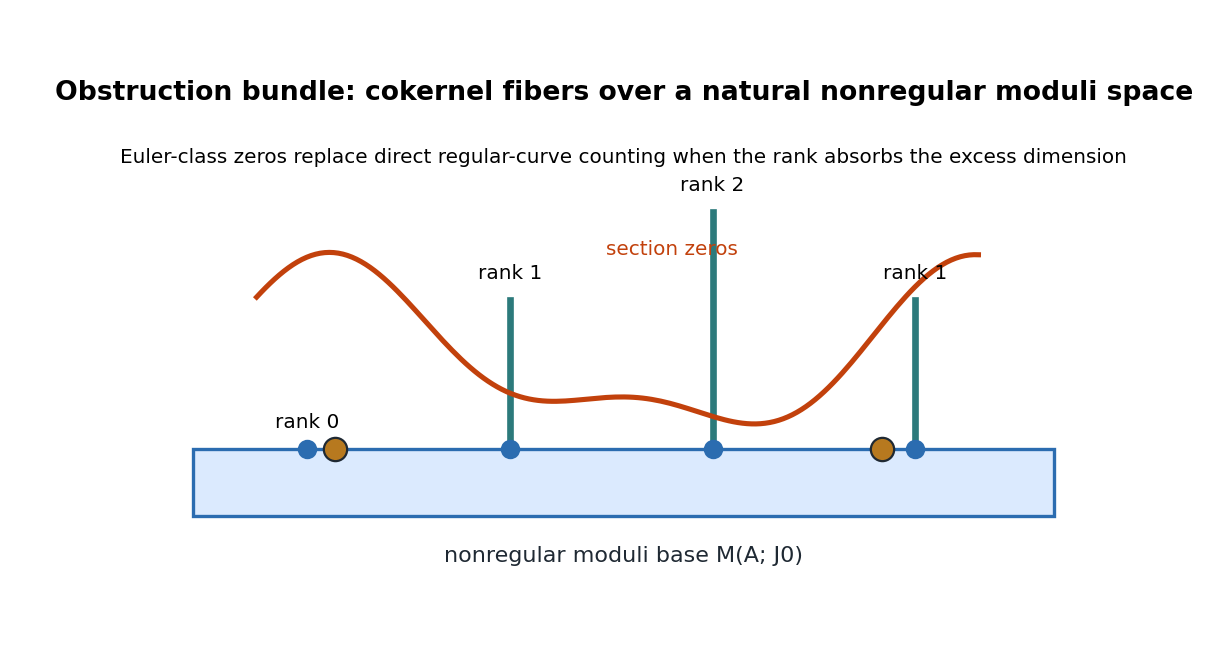

,case,base_dim,obstruction_rank,expected_zero_dim,interpretation,computed_zero_set_dim,balanced
0,regular count,0,0,0,ordinary signed count,0,True
1,excess line,1,1,0,Euler zero count,0,True
2,excess surface,2,2,0,top Chern/Euler count,0,True
3,unbalanced model,2,1,1,family remains,1,True


In [4]:
obstruction_cases = pd.DataFrame([
    {"case": "regular count", "base_dim": 0, "obstruction_rank": 0, "expected_zero_dim": 0, "interpretation": "ordinary signed count"},
    {"case": "excess line", "base_dim": 1, "obstruction_rank": 1, "expected_zero_dim": 0, "interpretation": "Euler zero count"},
    {"case": "excess surface", "base_dim": 2, "obstruction_rank": 2, "expected_zero_dim": 0, "interpretation": "top Chern/Euler count"},
    {"case": "unbalanced model", "base_dim": 2, "obstruction_rank": 1, "expected_zero_dim": 1, "interpretation": "family remains"},
])
obstruction_cases["computed_zero_set_dim"] = obstruction_cases["base_dim"] - obstruction_cases["obstruction_rank"]
obstruction_cases["balanced"] = obstruction_cases["computed_zero_set_dim"] == obstruction_cases["expected_zero_dim"]
obstruction_csv = TABLE_DIR / "obstruction-bundle-ledger.csv"
obstruction_cases.to_csv(obstruction_csv, index=False)

fig, ax = plt.subplots(figsize=(9.6, 5.2))
ax.set_xlim(-0.6, 4.1)
ax.set_ylim(-0.45, 3.2)
ax.set_axis_off()
base = Rectangle((0.1, 0.35), 3.4, 0.38, facecolor="#dbeafe", edgecolor=PALETTE["blue"], linewidth=1.5)
ax.add_patch(base)
ax.text(1.8, 0.18, "nonregular moduli base M(A; J0)", ha="center", va="top", fontsize=10, color=PALETTE["ink"])

xs = [0.55, 1.35, 2.15, 2.95]
heights = [0.0, 0.85, 1.35, 0.85]
labels = ["rank 0", "rank 1", "rank 2", "rank 1"]
for x, h, label in zip(xs, heights, labels):
    ax.plot([x, x], [0.73, 0.73 + h], color=PALETTE["teal"], linewidth=3 if h else 1.2)
    ax.scatter([x], [0.73], s=60, color=PALETTE["blue"], zorder=3)
    ax.text(x, 0.83 + h, label, ha="center", va="bottom", fontsize=9)

section_x = np.linspace(0.35, 3.2, 160)
section_y = 1.25 + 0.42 * np.sin(2.4 * section_x) - 0.18 * np.cos(5.0 * section_x)
ax.plot(section_x, section_y, color=PALETTE["red"], linewidth=2.3)
zeros = [0.66, 2.82]
ax.scatter(zeros, [0.73, 0.73], s=110, color=PALETTE["gold"], edgecolor=PALETTE["ink"], zorder=4)
ax.text(1.8, 2.72, "Obstruction bundle: cokernel fibers over a natural nonregular moduli space", ha="center", fontsize=12, weight="bold")
ax.text(1.8, 2.36, "Euler-class zeros replace direct regular-curve counting when the rank absorbs the excess dimension", ha="center", fontsize=9)
ax.text(1.73, 1.84, "section zeros", color=PALETTE["red"], fontsize=9)
obstruction_path = save_matplotlib(fig, UNIT, "figures", "obstruction-bundle-balance.png")
plt.close(fig)

obstruction_check = {
    "unit": UNIT,
    "cases": obstruction_cases.to_dict(orient="records"),
    "balanced_zero_dimensional_cases": int(((obstruction_cases["expected_zero_dim"] == 0) & obstruction_cases["balanced"]).sum()),
    "rank_balance_identity": "computed_zero_set_dim = base_dim - obstruction_rank",
}
obstruction_check["passed"] = bool((obstruction_cases["computed_zero_set_dim"] == obstruction_cases["base_dim"] - obstruction_cases["obstruction_rank"]).all() and obstruction_check["balanced_zero_dimensional_cases"] >= 3)
obstruction_check_path = save_json(obstruction_check, UNIT, "checks", "obstruction-bundle-check.json")

display_artifact(obstruction_path, width=820)
display_artifact(obstruction_csv)
obstruction_cases


## 3. Graph Counts, Splitting, and the Proof State

Graph counts replace a fixed almost complex structure on the target by a family `J_z` over the domain. The graph of a solution can be viewed in `S^2 x M`, and fixed marked points on the domain become part of the data. This is useful because the same invariant can often be represented with convenient fixed marks, then compared with ordinary Gromov-Witten counts.

The second half of the chapter uses the boundary of the moduli space of marked spheres. Splitting a curve at a node produces two lower-degree counts glued along the diagonal of the target. Keel's description of boundary relations in `Mbar_0,k` is the algebraic input that lets two ways of splitting four marked points be equated. In generating-function language, this is the WDVV equation; in `CP^2`, comparing coefficients gives Kontsevich's recursion for the numbers `N_d`.


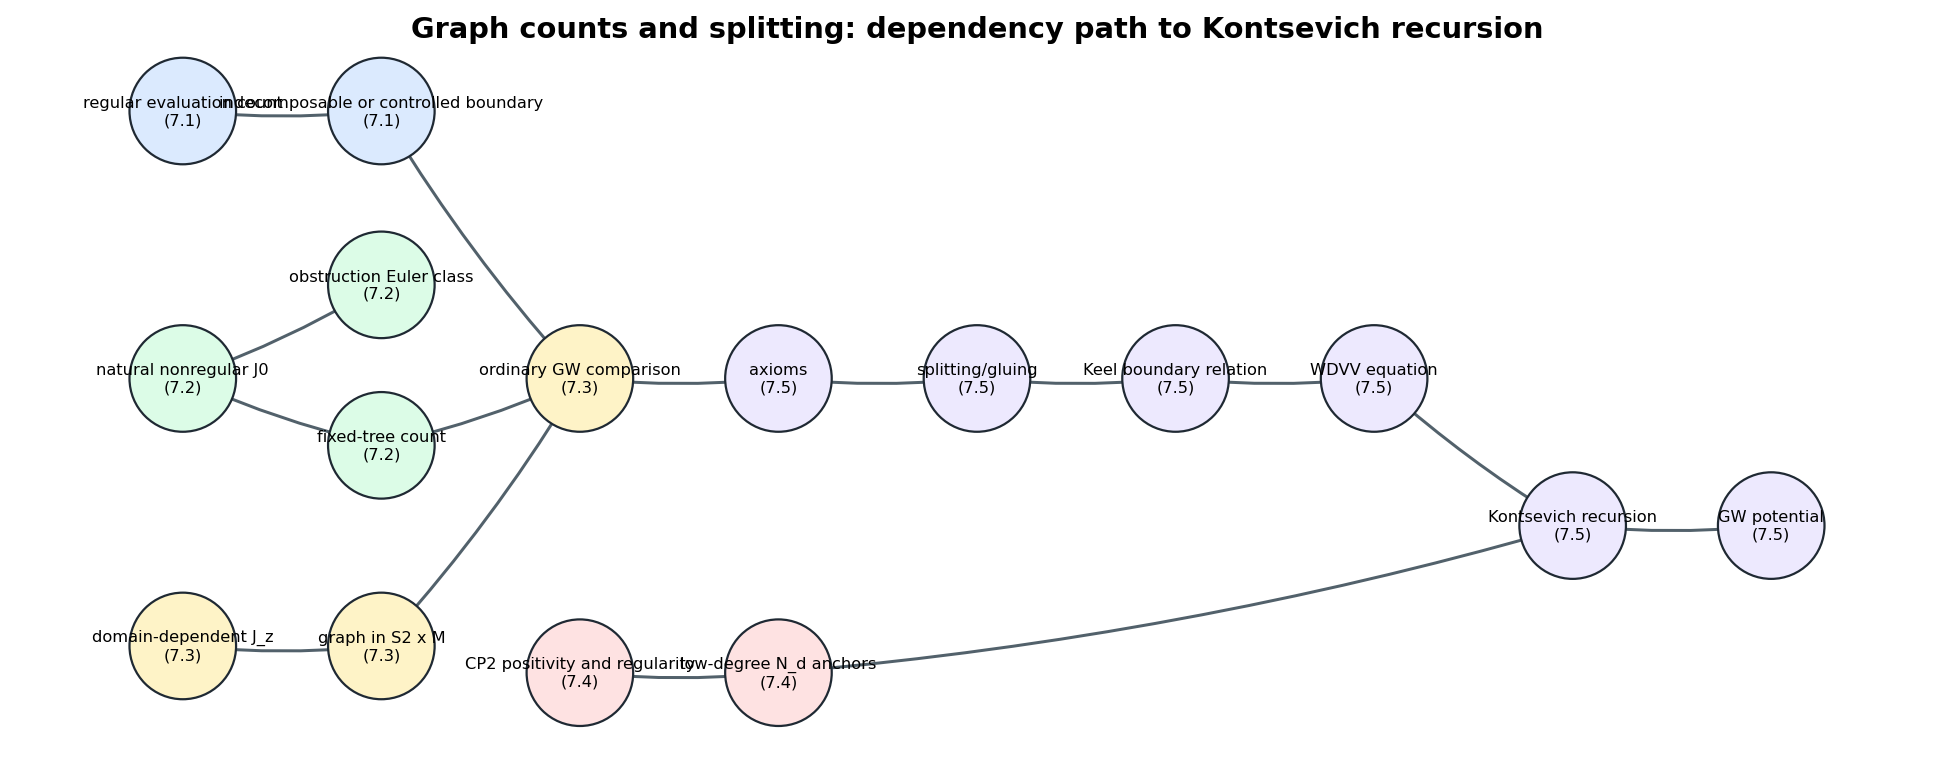

{'unit': 'chapter-07',
 'node_count': 16,
 'edge_count': 15,
 'is_directed_acyclic_graph': True,
 'has_graph_count_path': True,
 'has_splitting_to_recursion_path': True,
 'sections_represented': ['7.1', '7.2', '7.3', '7.4', '7.5'],
 'passed': True}

In [5]:
proof_nodes = {
    "regular evaluation count": "7.1",
    "indecomposable or controlled boundary": "7.1",
    "natural nonregular J0": "7.2",
    "obstruction Euler class": "7.2",
    "fixed-tree count": "7.2",
    "domain-dependent J_z": "7.3",
    "graph in S2 x M": "7.3",
    "ordinary GW comparison": "7.3",
    "CP2 positivity and regularity": "7.4",
    "low-degree N_d anchors": "7.4",
    "axioms": "7.5",
    "splitting/gluing": "7.5",
    "Keel boundary relation": "7.5",
    "WDVV equation": "7.5",
    "Kontsevich recursion": "7.5",
    "GW potential": "7.5",
}
proof_edges = [
    ("regular evaluation count", "indecomposable or controlled boundary"),
    ("indecomposable or controlled boundary", "ordinary GW comparison"),
    ("natural nonregular J0", "obstruction Euler class"),
    ("natural nonregular J0", "fixed-tree count"),
    ("fixed-tree count", "ordinary GW comparison"),
    ("domain-dependent J_z", "graph in S2 x M"),
    ("graph in S2 x M", "ordinary GW comparison"),
    ("ordinary GW comparison", "axioms"),
    ("CP2 positivity and regularity", "low-degree N_d anchors"),
    ("low-degree N_d anchors", "Kontsevich recursion"),
    ("axioms", "splitting/gluing"),
    ("splitting/gluing", "Keel boundary relation"),
    ("Keel boundary relation", "WDVV equation"),
    ("WDVV equation", "Kontsevich recursion"),
    ("Kontsevich recursion", "GW potential"),
]
G = nx.DiGraph()
for node, section in proof_nodes.items():
    G.add_node(node, section=section)
G.add_edges_from(proof_edges)

pos = {
    "regular evaluation count": (0.0, 3.0),
    "indecomposable or controlled boundary": (1.7, 3.0),
    "natural nonregular J0": (0.0, 2.0),
    "obstruction Euler class": (1.7, 2.35),
    "fixed-tree count": (1.7, 1.75),
    "domain-dependent J_z": (0.0, 1.0),
    "graph in S2 x M": (1.7, 1.0),
    "ordinary GW comparison": (3.4, 2.0),
    "CP2 positivity and regularity": (3.4, 0.9),
    "low-degree N_d anchors": (5.1, 0.9),
    "axioms": (5.1, 2.0),
    "splitting/gluing": (6.8, 2.0),
    "Keel boundary relation": (8.5, 2.0),
    "WDVV equation": (10.2, 2.0),
    "Kontsevich recursion": (11.9, 1.45),
    "GW potential": (13.6, 1.45),
}

fig, ax = plt.subplots(figsize=(15.5, 5.8))
node_colors = []
for node in G.nodes:
    section = G.nodes[node]["section"]
    node_colors.append({"7.1": "#dbeafe", "7.2": "#dcfce7", "7.3": "#fef3c7", "7.4": "#fee2e2", "7.5": "#ede9fe"}[section])

nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.35, edge_color="#52616b", connectionstyle="arc3,rad=0.05")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2300, node_color=node_colors, edgecolors=PALETTE["ink"], linewidths=1.0)
labels = {node: f"{node}\n({G.nodes[node]['section']})" for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=7.3)
ax.set_title("Graph counts and splitting: dependency path to Kontsevich recursion", fontsize=13, weight="bold")
ax.set_axis_off()
proof_graph_path = save_matplotlib(fig, UNIT, "figures", "graph-count-splitting-proof-graph.png")
legacy_proof_path = save_matplotlib(fig, UNIT, "figures", "proof-dependency-map.png")
plt.close(fig)

proof_check = {
    "unit": UNIT,
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "has_graph_count_path": nx.has_path(G, "domain-dependent J_z", "ordinary GW comparison"),
    "has_splitting_to_recursion_path": nx.has_path(G, "splitting/gluing", "Kontsevich recursion"),
    "sections_represented": sorted({G.nodes[node]["section"] for node in G.nodes}),
}
proof_check["passed"] = bool(proof_check["is_directed_acyclic_graph"] and proof_check["has_graph_count_path"] and proof_check["has_splitting_to_recursion_path"] and len(proof_check["sections_represented"]) == 5)
proof_check_path = save_json(proof_check, UNIT, "checks", "graph-count-splitting-proof-graph.json")
legacy_proof_check_path = save_json(proof_check, UNIT, "checks", "proof-dependency-map.json")

display_artifact(proof_graph_path, width=980)
proof_check


## 4. Axioms, the Potential, and Kontsevich Recursion

The axioms make Gromov-Witten invariants behave like a structured intersection theory. The effective axiom removes negative-area classes. Symmetry handles permutations of marks. Grading is the dimension test. The fundamental-class and divisor axioms simplify insertions. The splitting axiom is the computational engine: a nodal boundary is evaluated by summing over decompositions `A = A0 + A1` and over a Poincare-dual basis for the diagonal.

For `CP^2`, the potential packages the degree `d` counts `N_d` into one formal series. Keel's relation in the moduli of marked genus-zero curves gives WDVV. Extracting the coefficient for degree `d` yields Kontsevich's recursion. The table below uses the standard recursion only as a finite exact check, not as a black-box source of the theory.


In [6]:
def kontsevich_terms(d, counts):
    rows = []
    total = 0
    for d1 in range(1, d):
        d2 = d - d1
        bracket = d2 * math.comb(3 * d - 4, 3 * d1 - 2) - d1 * math.comb(3 * d - 4, 3 * d1 - 1)
        contribution = counts[d1] * counts[d2] * (d1 ** 2) * d2 * bracket
        rows.append({
            "d": int(d),
            "d1": int(d1),
            "d2": int(d2),
            "N_d1": int(counts[d1]),
            "N_d2": int(counts[d2]),
            "bracket": int(bracket),
            "contribution": int(contribution),
        })
        total += contribution
    return rows, int(total)


counts = {1: 1}
term_rows = []
summary_rows = [{"degree": 1, "computed_Nd": 1, "known_Nd": 1, "match": True, "nonzero_splitting_terms": 0}]
for d in range(2, 5):
    rows, total = kontsevich_terms(d, counts)
    counts[d] = total
    term_rows.extend(rows)
    summary_rows.append({
        "degree": int(d),
        "computed_Nd": int(total),
        "known_Nd": int(known_counts[d]),
        "match": bool(total == known_counts[d]),
        "nonzero_splitting_terms": int(sum(row["contribution"] != 0 for row in rows)),
    })

recursion_terms = pd.DataFrame(term_rows)
recursion_summary = pd.DataFrame(summary_rows)
terms_csv = TABLE_DIR / "kontsevich-recursion-terms.csv"
summary_csv = TABLE_DIR / "kontsevich-recursion-table.csv"
recursion_terms.to_csv(terms_csv, index=False)
recursion_summary.to_csv(summary_csv, index=False)

s, t1, t2 = sp.symbols("s t1 t2")
potential_fragment = sum(sp.Integer(counts[d]) * sp.exp(d * t1) * s**d * t2**(3 * d - 1) / sp.factorial(3 * d - 1) for d in range(1, 5))
coefficient_checks = {}
for d in range(1, 5):
    derivative = sp.diff(potential_fragment, t2, 3 * d - 1).subs({t2: 0, t1: 0})
    coefficient_checks[f"degree_{d}"] = int(sp.expand(derivative).coeff(s, d))

recursion_check = {
    "unit": UNIT,
    "formula": "N_d = sum_{d1+d2=d} N_d1 N_d2 d1^2 d2 [d2*C(3d-4,3d1-2) - d1*C(3d-4,3d1-1)]",
    "summary": recursion_summary.to_dict(orient="records"),
    "coefficient_checks_from_potential_fragment": coefficient_checks,
    "all_counts_match_known_low_degree_values": bool(recursion_summary["match"].all()),
    "known_low_degree_values": {str(k): int(v) for k, v in known_counts.items()},
}
recursion_check["passed"] = bool(recursion_check["all_counts_match_known_low_degree_values"] and coefficient_checks == {f"degree_{d}": known_counts[d] for d in range(1, 5)})
recursion_check_path = save_json(recursion_check, UNIT, "checks", "kontsevich-recursion-check.json")

display_artifact(summary_csv)
display_artifact(terms_csv)
recursion_summary


,degree,computed_Nd,known_Nd,match,nonzero_splitting_terms
0,1,1,1,True,0
1,2,1,1,True,1
2,3,12,12,True,1
3,4,620,620,True,3


## Applied Lab: Move Off the Zero-Dimensional Line

The count `N_d` is meaningful because the constraint choice lands on residual dimension zero. Change `d` or change the number of point constraints `k`, and the same moduli problem changes type. If `3d - k - 1` is positive, generic constraints leave a family. If it is negative, a generic configuration asks for too much. If it is zero, the problem is numerically eligible to be a count, and the analytic hypotheses decide whether the number is invariant.

Use the grid as a lab sheet. Pick a degree, hover over nearby values of `k`, and compare the residual dimension with the status label. The diagonal `k = 3d - 1` is the CP2 rational-curve counting line used in the previous ledger.


In [7]:
def residual_dimension_cp2(degree, point_constraints):
    return int(3 * int(degree) - int(point_constraints) - 1)


def classify_residual(residual):
    if residual > 0:
        return "family"
    if residual == 0:
        return "isolated count candidate"
    return "overconstrained"


lab_rows = []
for d in range(1, 7):
    for k in range(0, 18):
        residual = residual_dimension_cp2(d, k)
        lab_rows.append({
            "degree": d,
            "point_constraints": k,
            "residual_complex_dim": residual,
            "status": classify_residual(residual),
            "on_counting_line": k == 3 * d - 1,
        })
lab = pd.DataFrame(lab_rows)
lab_csv = TABLE_DIR / "degree-constraint-lab-grid.csv"
lab.to_csv(lab_csv, index=False)

z = lab.pivot(index="degree", columns="point_constraints", values="residual_complex_dim").sort_index(ascending=False)
hover = []
for degree in z.index:
    hover_row = []
    for k in z.columns:
        row = lab[(lab["degree"] == degree) & (lab["point_constraints"] == k)].iloc[0]
        hover_row.append(f"degree d={degree}<br>points k={k}<br>residual={row['residual_complex_dim']}<br>{row['status']}")
    hover.append(hover_row)

fig = go.Figure(data=go.Heatmap(
    z=z.values,
    x=[int(c) for c in z.columns],
    y=[int(i) for i in z.index],
    text=hover,
    hoverinfo="text",
    colorscale=[[0.0, "#b2182b"], [0.48, "#fddbc7"], [0.50, "#f7f7f7"], [0.52, "#d1e5f0"], [1.0, "#2166ac"]],
    zmid=0,
    colorbar=dict(title="residual dim"),
))
fig.add_trace(go.Scatter(
    x=[3 * d - 1 for d in range(1, 7)],
    y=list(range(1, 7)),
    mode="markers+lines",
    marker=dict(color="#111827", size=8),
    line=dict(color="#111827", width=2),
    name="k = 3d - 1",
    hovertemplate="counting line<extra></extra>",
))
fig.update_layout(
    title="Applied lab: degree and point constraints in CP2",
    xaxis_title="point constraints k",
    yaxis_title="degree d",
    template="plotly_white",
    width=850,
    height=470,
)
lab_html = HTML_DIR / "degree-constraint-lab.html"
fig.write_html(lab_html, include_plotlyjs="cdn", full_html=True)

lab_samples = pd.DataFrame([
    {"degree": 3, "point_constraints": 7, "residual_complex_dim": residual_dimension_cp2(3, 7), "status": classify_residual(residual_dimension_cp2(3, 7))},
    {"degree": 3, "point_constraints": 8, "residual_complex_dim": residual_dimension_cp2(3, 8), "status": classify_residual(residual_dimension_cp2(3, 8))},
    {"degree": 3, "point_constraints": 9, "residual_complex_dim": residual_dimension_cp2(3, 9), "status": classify_residual(residual_dimension_cp2(3, 9))},
])
lab_check = {
    "unit": UNIT,
    "grid_rows": int(len(lab)),
    "degrees": list(range(1, 7)),
    "constraint_values": list(range(0, 18)),
    "zero_line_pairs": lab.loc[lab["on_counting_line"], ["degree", "point_constraints"]].to_dict(orient="records"),
    "sample_classifications": lab_samples.to_dict(orient="records"),
}
lab_check["passed"] = bool(len(lab_check["zero_line_pairs"]) == 6 and set(lab_samples["status"]) == {"family", "isolated count candidate", "overconstrained"})
lab_check_path = save_json(lab_check, UNIT, "checks", "degree-constraint-lab-check.json")

display_artifact(lab_html, width="100%", height=520)
display_artifact(lab_csv)
lab_samples


,degree,point_constraints,residual_complex_dim,status
0,3,7,1,family
1,3,8,0,isolated count candidate
2,3,9,-1,overconstrained


## Takeaways

A genus-zero Gromov-Witten invariant is not simply a visible set of curves. It is an oriented intersection number built from an evaluation pseudocycle after the dimension, compactness, and boundary-control tests have been passed.

The projective-plane examples are useful because the dimension arithmetic is small enough to audit. For degree `d` rational curves in `CP^2`, `3d - 1` point constraints give residual dimension zero, and the first counts are `1, 1, 12, 620`.

The axioms are computational data. Splitting and gluing turn nodal boundary strata into products of lower-degree invariants. Keel's relation supplies the comparison of boundary divisors, WDVV expresses the comparison in the potential, and Kontsevich's recursion is the coefficient-level output for `CP^2`.


## Final Sanity Checks

The final cell checks the planning artifacts, the CP2 ledger, the graph/splitting proof visual, the obstruction-bundle ledger, the recursion table, the applied lab, and the final summary JSON. It also rechecks the mathematical identities used in the notebook: residual dimension zero for degrees `1..4`, obstruction rank balance, graph reachability to recursion, and exact low-degree Kontsevich counts.


In [8]:
required_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    FIG_DIR / "gromov-witten-cp2-count-ledger.png",
    TABLE_DIR / "dimension-zero-ledger.csv",
    CHECK_DIR / "dimension-zero-ledger.json",
    FIG_DIR / "obstruction-bundle-balance.png",
    CHECK_DIR / "obstruction-bundle-check.json",
    FIG_DIR / "graph-count-splitting-proof-graph.png",
    CHECK_DIR / "graph-count-splitting-proof-graph.json",
    TABLE_DIR / "kontsevich-recursion-table.csv",
    TABLE_DIR / "kontsevich-recursion-terms.csv",
    CHECK_DIR / "kontsevich-recursion-check.json",
    HTML_DIR / "degree-constraint-lab.html",
    TABLE_DIR / "degree-constraint-lab-grid.csv",
    CHECK_DIR / "degree-constraint-lab-check.json",
]

assert_artifact(CHECK_DIR / "source-coverage.json", min_bytes=128)
assert_artifact(CHECK_DIR / "library-routing.json", min_bytes=128)
assert_artifact(CHECK_DIR / "visual-storyboard.json", min_bytes=128)
assert_artifact(FIG_DIR / "gromov-witten-cp2-count-ledger.png", min_bytes=4096)
assert_artifact(FIG_DIR / "graph-count-splitting-proof-graph.png", min_bytes=4096)
assert_artifact(FIG_DIR / "obstruction-bundle-balance.png", min_bytes=4096)
assert_artifact(TABLE_DIR / "kontsevich-recursion-table.csv", min_bytes=128)
assert_artifact(HTML_DIR / "degree-constraint-lab.html", min_bytes=4096)

for path in required_artifacts:
    assert_artifact(path, min_bytes=128)

loaded_checks = {path.name: json.loads(path.read_text(encoding="utf-8")) for path in [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "dimension-zero-ledger.json",
    CHECK_DIR / "obstruction-bundle-check.json",
    CHECK_DIR / "graph-count-splitting-proof-graph.json",
    CHECK_DIR / "kontsevich-recursion-check.json",
    CHECK_DIR / "degree-constraint-lab-check.json",
]}

ledger_check_df = pd.read_csv(TABLE_DIR / "dimension-zero-ledger.csv")
recursion_check_df = pd.read_csv(TABLE_DIR / "kontsevich-recursion-table.csv")
obstruction_check_df = pd.read_csv(TABLE_DIR / "obstruction-bundle-ledger.csv")

final_sanity = {
    "unit": UNIT,
    "artifact_count_checked": len(required_artifacts),
    "all_json_checks_passed": all(data.get("passed") is True for data in loaded_checks.values()),
    "cp2_residual_dimensions_zero": bool((ledger_check_df["residual_complex_dim"] == 0).all()),
    "cp2_counts_match": bool(ledger_check_df["known_count_Nd"].tolist() == [1, 1, 12, 620]),
    "obstruction_rank_balance": bool((obstruction_check_df["computed_zero_set_dim"] == obstruction_check_df["base_dim"] - obstruction_check_df["obstruction_rank"]).all()),
    "kontsevich_counts_match": bool(recursion_check_df["match"].all()),
    "graph_reaches_recursion": bool(loaded_checks["graph-count-splitting-proof-graph.json"]["has_splitting_to_recursion_path"]),
    "lab_zero_line_count": int(len(loaded_checks["degree-constraint-lab-check.json"]["zero_line_pairs"])),
}
final_sanity["passed"] = bool(
    final_sanity["all_json_checks_passed"]
    and final_sanity["cp2_residual_dimensions_zero"]
    and final_sanity["cp2_counts_match"]
    and final_sanity["obstruction_rank_balance"]
    and final_sanity["kontsevich_counts_match"]
    and final_sanity["graph_reaches_recursion"]
    and final_sanity["lab_zero_line_count"] == 6
)
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(final_sanity_path, min_bytes=128)
assert final_sanity["passed"] is True, final_sanity

print(json.dumps(final_sanity, indent=2))


{
  "unit": "chapter-07",
  "artifact_count_checked": 16,
  "all_json_checks_passed": true,
  "cp2_residual_dimensions_zero": true,
  "cp2_counts_match": true,
  "obstruction_rank_balance": true,
  "kontsevich_counts_match": true,
  "graph_reaches_recursion": true,
  "lab_zero_line_count": 6,
  "passed": true
}
